# EDA CSV PIANTE

In [2]:
# Importare le librerie
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
import category_encoders as ce
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import RobustScaler

In [3]:
# Leggere il file CSV 'plants.csv' e caricarlo in un DataFrame 
df = pd.read_csv('plants.csv')
print(df)

       occurrence_no record_type  reid_no flags  collection_no  \
0              31284         occ      NaN   NaN           2260   
1              45807         occ      NaN   NaN           3640   
2              77082         occ      NaN   NaN           1573   
3              77169         occ      NaN   NaN           1567   
4              82793         occ      NaN   NaN           1555   
...              ...         ...      ...   ...            ...   
57389        2064914         occ      NaN   NaN         278854   
57390        2064915         occ      NaN   NaN         278854   
57391        2064916         occ      NaN   NaN         278854   
57392        2064922         occ      NaN   NaN         278854   
57393        2064923         occ      NaN   NaN         278854   

                  identified_name identified_rank  identified_no  \
0                    Algae indet.           class            NaN   
1         ? Caryophyllidae indet.        subclass            NaN   
2  

In [4]:
# Prime cinque righe
df.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,31284,occ,NaN,NaN,2260,Algae indet.,class,NaN,NaN,Algae,...,This is a collection based on a composite of t...,121.0,Alikper,NaN,NaN,NO_PHYLUM_SPECIFIED,Algae,NaN,NaN,NaN
1,45807,occ,NaN,NaN,3640,? Caryophyllidae indet.,subclass,NaN,NaN,Caryophyllidae,...,Pitt Island,39.0,Kahuitara Tuff,NaN,NaN,Angiospermae,Dicotyledoneae,NaN,NaN,NaN
2,77082,occ,NaN,NaN,1573,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77169,occ,NaN,NaN,1567,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,82793,occ,NaN,NaN,1555,Diplopora versipora,genus,NaN,species not entered,Diplopora,...,coastal cliff between Black Head and Shortlake,126.0,Trigonia clavellata,NaN,NaN,Chlorophyta,Chlorophyceae,Dasycladales,Diploporaceae,Diplopora


In [5]:
# Informazioni generali
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     57394 non-null  int64  
 1   record_type       57394 non-null  str    
 2   reid_no           167 non-null    float64
 3   flags             14503 non-null  str    
 4   collection_no     57394 non-null  int64  
 5   identified_name   57394 non-null  str    
 6   identified_rank   57394 non-null  str    
 7   identified_no     3597 non-null   float64
 8   difference        11512 non-null  str    
 9   accepted_name     57394 non-null  str    
 10  accepted_attr     56253 non-null  str    
 11  accepted_rank     57394 non-null  str    
 12  accepted_no       57394 non-null  int64  
 13  early_interval    57394 non-null  str    
 14  late_interval     19454 non-null  str    
 15  max_ma            57394 non-null  float64
 16  min_ma            57394 non-null  float64
 17  refe

## VALORI MANCANTI

In [6]:
# Valori NaN per colonna
df.isnull().sum()

occurrence_no           0
record_type             0
reid_no             57227
flags               42891
collection_no           0
identified_name         0
identified_rank         0
identified_no       53797
difference          45882
accepted_name           0
accepted_attr        1141
accepted_rank           0
accepted_no             0
early_interval          0
late_interval       37940
max_ma                  0
min_ma                  0
reference_no            0
lng                     0
lat                     0
cc                      0
state               20247
county              46988
latlng_basis         4152
latlng_precision        0
altitude_value      51578
altitude_unit       52857
geogscale           30182
geogcomments        29262
cx_int_no              70
formation           12943
geological_group    49478
member              51137
phylum                482
class                1100
order                1847
family               2210
genus                2646
dtype: int64

In [7]:
# Percentuale di valori nulli per ogni colonna
(df.isnull().sum() / len(df) * 100).round(2)

occurrence_no        0.00
record_type          0.00
reid_no             99.71
flags               74.73
collection_no        0.00
identified_name      0.00
identified_rank      0.00
identified_no       93.73
difference          79.94
accepted_name        0.00
accepted_attr        1.99
accepted_rank        0.00
accepted_no          0.00
early_interval       0.00
late_interval       66.10
max_ma               0.00
min_ma               0.00
reference_no         0.00
lng                  0.00
lat                  0.00
cc                   0.00
state               35.28
county              81.87
latlng_basis         7.23
latlng_precision     0.00
altitude_value      89.87
altitude_unit       92.09
geogscale           52.59
geogcomments        50.98
cx_int_no            0.12
formation           22.55
geological_group    86.21
member              89.10
phylum               0.84
class                1.92
order                3.22
family               3.85
genus                4.61
dtype: float

In [8]:
# Colonna cc --> codice paese
# Tra le righe con 'state' mancante, conto i 10 paesi (cc) più frequenti
# per capire se i null sono concentrati in specifici paesi
df[df['state'].isnull()]['cc'].value_counts().head(10)

cc
RU    5949
AQ    1502
TJ    1151
KZ     874
RO     739
FR     690
NO     606
GL     601
IL     600
GE     544
Name: count, dtype: int64

è un'assenza strutturale, non un errore di qualità dei dati → stessa strategia di gestione, sostituire NaN con "Non specificato" invece di eliminare le righe.

In [9]:
# Tra le righe con 'formation' mancante, conto i 10 paesi (cc) più frequenti
# per capire se anche qui i null sono concentrati geograficamente
df[df['formation'].isnull()]['cc'].value_counts().head(10)

cc
RU    1239
CN    1092
IN     854
FR     769
EG     680
NO     585
BR     519
RO     497
TJ     462
DE     404
Name: count, dtype: int64

per formation non sembra esserci un singolo paese "responsabile" della maggior parte dei null come per state. È più probabile che la mancanza di formazione geologica dipenda da come è stato registrato il singolo ritrovamento (es. scavi più datati o meno dettagliati) piuttosto che da una convenzione nazionale sistematica. Vale comunque la pena tenerlo a mente, ma la causa è probabilmente più mista.

In [10]:
# Tra le righe con 'geological_group' mancante, conto i 10 paesi (cc) più frequenti
df[df['geological_group'].isnull()]['cc'].value_counts().head(10)

cc
RU    5959
US    5607
CN    4761
AR    4099
BR    3428
IN    2677
EG    2190
AU    1558
TJ    1151
CA    1126
Name: count, dtype: int64

In [11]:
# Tra le righe con 'member' mancante, conto i 10 paesi (cc) più frequenti
df[df['member'].isnull()]['cc'].value_counts().head(10)

cc
RU    6116
CN    5138
US    4706
AR    3714
BR    2830
IN    2799
CA    1842
EG    1642
AU    1501
AQ    1405
Name: count, dtype: int64

In [12]:
# Distribuzione generale dei paesi nel dataset intero, per confronto
df['cc'].value_counts().head(10)

cc
RU    6208
US    6078
CN    5245
AR    4864
BR    3590
IN    2838
EG    2191
CA    2052
AU    1974
AQ    1638
Name: count, dtype: int64

Stessa analisi geografica fatta per `state` e `formation`: ho confrontato i paesi più frequenti tra i record con `geological_group`/`member` mancanti rispetto alla distribuzione generale dei paesi nel dataset.

Risultato:le due distribuzioni coincidono quasi esattamente (RU, US, CN, AR, BR in testa in entrambi i casi). Questo significa che la mancanza di questi due campi **non è legata a un paese specifico**, ma è diffusa in modo uniforme su tutto il dataset — coerente con le percentuali di nulli molto alte (86.21% e 89.10%).

Strategia di gestione: stessa imputazione con `"Non specificato"` invece della rimozione delle righe, ma per una motivazione diversa rispetto a `state` — qui non c'è una causa "nazionale", è semplicemente un dato raramente disponibile in generale.

In [13]:
# Controllo placeholder testuali tipo "NO_..._SPECIFIED" in phylum
df['phylum'].value_counts(dropna=False).head(10)

phylum
Pteridophyta           16141
Gymnospermae            8378
Angiospermae            7308
Ginkgophyta             4648
Equisetophyta           3357
Cycadophyta             3009
NO_PHYLUM_SPECIFIED     2663
Chlorophyta             1787
Spermatophyta           1679
Lycopodiophyta          1487
Name: count, dtype: int64

In [14]:
# Controllo placeholder testuali in class
df['class'].value_counts(dropna=False).head(10)

class
NO_CLASS_SPECIFIED    21096
Polypodiopsida        12665
Ginkgoopsida           4301
Equisetopsida          3355
Cycadopsida            2494
Pteridopsida           2149
Lycopodiopsida         1486
Chlorophyceae          1331
NaN                    1100
Gnetopsida             1016
Name: count, dtype: int64

In [15]:
# Controllo placeholder testuali in order
df['order'].value_counts(dropna=False).head(10)

order
NO_ORDER_SPECIFIED    23150
Coniferales            4011
Bennettitales          3149
Cycadales              2300
Equisetales            1880
NaN                    1847
Ginkgoales             1545
Schizaeales            1314
Czekanowskiales        1243
Cyatheales             1222
Name: count, dtype: int64

In [16]:
# Controllo placeholder testuali in family
df['family'].value_counts(dropna=False).head(10)

family
NO_FAMILY_SPECIFIED    29493
Podocarpaceae           2823
NaN                     2210
Araucariaceae           1929
Cyatheaceae             1216
Equisetaceae            1196
Schizaeaceae            1009
Ginkgoaceae              978
Cheirolepidiaceae        974
Gleicheniaceae           721
Name: count, dtype: int64

In [17]:
# Controllo placeholder testuali in genus
df['genus'].value_counts(dropna=False).head(10)

genus
NaN                    2646
Cladophlebis           2364
Coniopteris            1173
Nilsonia               1007
Podozamites             924
Equisetites             878
Ephedripites            838
Classopollis            827
Pterophyllum            808
Cicatricosisporites     769
Name: count, dtype: int64

In [18]:
import numpy as np

# Sostituire i placeholder con NaN veri nelle colonne tassonomiche
colonne_tassonomiche = ['phylum', 'class', 'order', 'family']
for col in colonne_tassonomiche:
    df[col] = df[col].replace(r'^NO_.*_SPECIFIED$', np.nan, regex=True)

In [19]:
# Ricalcolare le percentuali aggiornate per avere la versione corretta
df[colonne_tassonomiche].isnull().mean().sort_values(ascending=False) * 100

family    55.237481
order     43.553333
class     38.673032
phylum     5.479667
dtype: float64

Colonne tassonomiche (phylum, class, order, family)

Controllo preliminare: nel dataset, oltre ai NaN veri, sono presenti placeholder testuali (`NO_PHYLUM_SPECIFIED`, `NO_CLASS_SPECIFIED`, ecc.) che `isnull()` non rileva, mascherando la reale percentuale di dati mancanti.

Confronto prima/dopo la normalizzazione dei placeholder:

| Colonna | % null (solo NaN) | % null (NaN + placeholder) |
|---|---|---|
| phylum | 0.84% | 5.48% |
| class | 1.92% | 38.67% |
| order | 3.22% | 43.55% |
| family | 3.85% | 55.24% |

La differenza è enorme, soprattutto su `order` e `family`, dove più del 40-55% dei record non ha questo livello di dettaglio tassonomico. 

Strategia di gestione: placeholder normalizzati a NaN veri, poi stessa imputazione con `"Non specificato"` usata per le altre colonne — fondamentale per coerenza nel resto della pipeline ETL.

## VALORI DUPLICATI

In [20]:
# Conteggio righe duplicate
df.duplicated().sum()

np.int64(0)

0 righe duplicate sull'intero dataset. Non sono necessarie azioni di deduplicazione in fase ETL.

## CONTEGGI PER CATEGORIA

In [21]:
# Distribuzione tassonomica
df['phylum'].value_counts()

phylum
Pteridophyta          16141
Gymnospermae           8378
Angiospermae           7308
Ginkgophyta            4648
Equisetophyta          3357
Cycadophyta            3009
Chlorophyta            1787
Spermatophyta          1679
Lycopodiophyta         1487
Magnoliophyta          1221
Gnetophyta             1016
Rhodophyta              790
Peltaspermophyta        668
Bryophyta               638
Tracheophyta            557
Lycophyta               332
Coniferophyta           318
Marchantiophyta         279
Embryophyta             202
Charophyta              173
Cycadeoideophyta         95
Sphenophyta              73
Lycopodophyta            51
Pteridospermophyta       41
Filicophyta               1
Name: count, dtype: int64

In [22]:
# Distribuzione temporale
df['early_interval'].value_counts()

early_interval
Late Jurassic      3395
Maastrichtian      3038
Albian             2846
Carnian            2510
Middle Jurassic    2284
                   ... 
Raricostatum          1
Arowhanan             1
Davoei                1
Ibex                  1
Motuan                1
Name: count, Length: 127, dtype: int64

In [23]:
# Distribuzione geografica
df['cc'].value_counts()

cc
RU    6208
US    6078
CN    5245
AR    4864
BR    3590
      ... 
MW       1
GY       1
CR       1
BJ       1
KH       1
Name: count, Length: 118, dtype: int64

In [24]:
# Formazioni geologiche più frequenti
df['formation'].value_counts().head(10)

formation
Hell Creek         1810
Riachuelo          1022
Agua Doce           732
Bathurst Island     697
Molteno             673
Monte Chico         661
La Colonia          605
Chorrillo           592
Saltwick            539
Bentiu              521
Name: count, dtype: int64

Interpretazione conteggi per categoria

- **phylum**: Pteridophyta è il phylum più numeroso (16.141 record, ~28% del totale), seguita da Gymnospermae (8.378) e Angiospermae (7.308). Il dataset è dominato da piante vascolari primitive e gimnosperme, coerente con la copertura Triassico–Cretaceo (le angiosperme esplodono solo nel Cretaceo tardivo).

- **early_interval**: 127 valori distinti, molto frammentato — Late Jurassic (3.395) e Maastrichtian (3.038) in testa. Come per i dinosauri, troppo granulare per la dashboard: sarà necessario raggruppare in `period_group` (Triassico/Giurassico/Cretaceo) in fase ETL.

- **cc**: 118 paesi diversi, fortemente concentrati su Russia (6.208), USA (6.078), Cina (5.245), Argentina (4.864) e Brasile (3.590). La distribuzione geografica è diffusa ma sbilanciata verso l'emisfero nord — utile per le visualizzazioni geografiche della dashboard.

- **formation**: Hell Creek è la formazione più rappresentata (1.810), seguita da Riachuelo (1.022) e Agua Doce (732) — probabili hotspot floristici da evidenziare in dashboard, e coincidenza interessante con Hell Creek già presente nei dinosauri.

## STATISTICHE DESCRITTIVE

In [25]:
df[['max_ma', 'min_ma', 'lng', 'lat']].describe()

,max_ma,min_ma,lng,lat
count,57394.000000,57394.000000,57394.000000,57394.000000
mean,149.337731,135.531882,12.532439,22.700500
std,55.096272,53.936862,80.320561,35.479272
min,72.200000,0.000000,-176.000000,-84.000000
25%,100.500000,93.900000,-68.006386,2.620556
50%,143.100000,121.400000,21.850000,36.540901
75%,192.900000,174.700000,79.000000,46.398056
max,298.900000,250.500000,177.083328,81.949997


In [28]:
# Un solo record ha min_ma = 0.0 (Plantae indet., late_interval = "Cenozoic")
# Non è un errore di data entry, ma una datazione con range molto ampio
# Caso isolato: non richiede rimozione
df[df['min_ma'] < 10][['identified_name', 'early_interval', 'late_interval', 'max_ma', 'min_ma']].head(10)

,identified_name,early_interval,late_interval,max_ma,min_ma
49597,Plantae indet.,Cretaceous,Cenozoic,143.1,0.0


**Interpretazione statistiche descrittive**

Il range temporale (`max_ma`/`min_ma`) va da ~72 a ~298.9 milioni di anni, coerente con il filtro Triassico–Cretaceo. Un'unica eccezione: un singolo record (`Plantae indet.`, riga 49597) ha `min_ma` = 0.0 perché il suo `late_interval` è "Cenozoic" — un range stratigrafico molto ampio per identificazione incerta, non un errore di data entry. Essendo isolato (1 record su 57.394), non richiede correzione né esclusione, ma viene segnalato come nota di qualità dati.

Le coordinate (`lng`, `lat`) coprono l'intero globo (-176/177 di longitudine, -84/82 di latitudine), senza valori fuori range fisico — nessuna anomalia geografica da correggere.

## VISUALIZZAZIONI

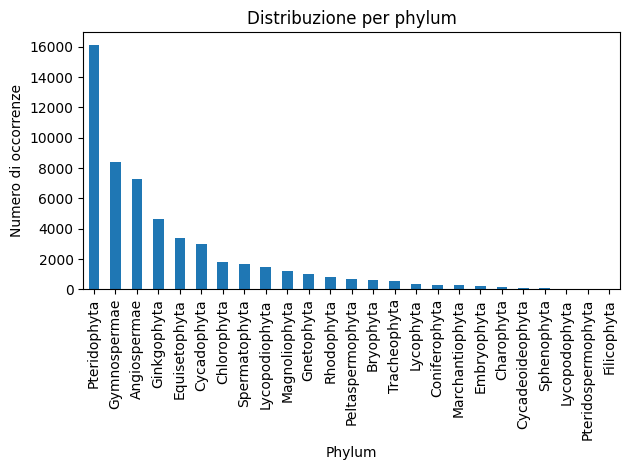

In [27]:
df['phylum'].value_counts().plot(kind='bar')
plt.title('Distribuzione per phylum')
plt.xlabel('Phylum')
plt.ylabel('Numero di occorrenze')
plt.tight_layout()
plt.show()

Il grafico conferma la netta prevalenza di Pteridophyta, seguita da Gymnospermae e Angiospermae. La distribuzione riflette la composizione tipica della flora mesozoica: le piante vascolari primitive e le gimnosperme dominano per tutto il periodo, mentre le angiosperme (piante a fiore) appaiono significativamente solo nel Cretaceo.

## Conclusioni EDA — plants.csv

**Attributi disponibili:** il dataset contiene 38 colonne che coprono identificazione tassonomica (`identified_name`, `accepted_name`, `phylum`, `class`, `order`, `family`, `genus`), localizzazione geografica (`lng`, `lat`, `cc`, `state`, `county`), informazioni temporali (`early_interval`, `late_interval`, `max_ma`, `min_ma`) e stratigrafiche (`formation`, `geological_group`, `member`). La struttura è identica a `dinos.csv`, il che rende possibile una star schema unificata con `dataset_type` come discriminante.

**Tipologie di dati:** principalmente stringhe (nomi, classificazioni, paesi) e numerici float/int (coordinate, età in milioni di anni, identificativi).

**Valori mancanti:** presenti e strutturali. Le colonne più colpite sono `family` (**55.24%**, corretto da `NO_FAMILY_SPECIFIED`), `order` (**43.55%**, corretto da `NO_ORDER_SPECIFIED`), `class` (**38.67%**, corretto da `NO_CLASS_SPECIFIED`) e `county` (~81.87%). Il controllo `value_counts(dropna=False)` ha rivelato placeholder testuali su `phylum`, `class`, `order` e `family` non intercettati da `isnull()` — normalizzati a NaN prima del calcolo finale. Per `state`, `geological_group` e `member` i null sono diffusi geograficamente e non attribuibili a un singolo paese. Strategia uniforme: sostituzione con `"Non specificato"` invece della rimozione delle righe.

**Duplicati:** nessuna riga duplicata (0 su 57.394 record).

**Campi utili per l'analisi:** `phylum` (Pteridophyta dominante al ~28%), `early_interval` (da raggruppare in `period_group`: Triassico/Giurassico/Cretaceo), `cc` (118 paesi, concentrati su RU/US/CN/AR/BR) e `formation` (Hell Creek come hotspot principale, condiviso con il dataset dinosauri) sono i campi più rilevanti per le visualizzazioni della dashboard Power BI e per rispondere alle domande analitiche del progetto — in particolare la co-presenza geografica e temporale tra flora e fauna.